## Deep Image Prior (DIP) 单图反卷积

- **观测**：`original_image.png`（视为已模糊观测 \(y\)）
- **PSF**：从 `psf_kernel.png` **按峰值裁剪**、归一化（和为 1），再用于频域前向模型 \(y \approx k * f_\theta(z)\)
- **前向**：`psf2otf` 采用 **居中嵌入 + ifftshift**，与周期卷积 / `fft2` 约定一致
- 大图会占用显存：可用 `MAX_SIDE` 对图像与 PSF **同步缩放**后再训练

运行顺序：从上到下依次执行。

In [1]:
import os
from typing import Optional
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from scipy.ndimage import zoom


class UNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, features=None):
        if features is None:
            features = [32, 64, 128, 256]
        super().__init__()
        self.downs = nn.ModuleList()
        self.ups = nn.ModuleList()
        self.pool = nn.MaxPool2d(2, 2)
        ch = in_channels
        for f in features:
            self.downs.append(self._conv_block(ch, f))
            ch = f
        self.bottleneck = self._conv_block(features[-1], features[-1] * 2)
        for f in reversed(features):
            self.ups.append(nn.ConvTranspose2d(f * 2, f, 2, 2))
            self.ups.append(self._conv_block(f * 2, f))
        self.final_conv = nn.Conv2d(features[0], out_channels, 1)

    def _conv_block(self, c_in, c_out):
        return nn.Sequential(
            nn.Conv2d(c_in, c_out, 3, padding=1),
            nn.BatchNorm2d(c_out),
            nn.ReLU(True),
            nn.Conv2d(c_out, c_out, 3, padding=1),
            nn.BatchNorm2d(c_out),
            nn.ReLU(True),
        )

    def forward(self, x):
        skips = []
        for down in self.downs:
            x = down(x)
            skips.append(x)
            x = self.pool(x)
        x = self.bottleneck(x)
        skips = skips[::-1]
        for idx in range(0, len(self.ups), 2):
            x = self.ups[idx](x)
            skip = skips[idx // 2]
            if x.shape[2:] != skip.shape[2:]:
                x = F.interpolate(x, size=skip.shape[2:], mode="bilinear", align_corners=False)
            x = torch.cat([skip, x], dim=1)
            x = self.ups[idx + 1](x)
        return self.final_conv(x)


def crop_psf_from_image(psf_full: np.ndarray, crop_size: int, center=None) -> np.ndarray:
    """按最大值位置裁剪奇数尺寸 PSF，无插值；能量归一化。"""
    psf_full = np.asarray(psf_full, dtype=np.float64)
    if psf_full.ndim == 3:
        psf_full = np.mean(psf_full, axis=2)
    if center is None:
        center = np.unravel_index(np.argmax(psf_full), psf_full.shape)
    half = crop_size // 2
    y, x = int(center[0]), int(center[1])
    pad_y = max(0, half - y, (y + half) - (psf_full.shape[0] - 1))
    pad_x = max(0, half - x, (x + half) - (psf_full.shape[1] - 1))
    if pad_y > 0 or pad_x > 0:
        psf_full = np.pad(psf_full, ((pad_y, pad_y), (pad_x, pad_x)), mode="constant")
        y += pad_y
        x += pad_x
    cropped = psf_full[y - half : y + half + 1, x - half : x + half + 1]
    s = cropped.sum()
    if s > 0:
        cropped = cropped / s
    return cropped.astype(np.float32)


def load_grayscale(path: str) -> np.ndarray:
    img = Image.open(path).convert("L")
    return np.asarray(img, dtype=np.float32) / 255.0


def resize_pair_for_dip(
    blurred: np.ndarray, psf: np.ndarray, max_side: Optional[int]
):
    """将观测与 PSF 同步缩小，便于 U-Net 与显存；PSF 用 zoom 保持和为 1。"""
    if max_side is None or max_side <= 0:
        return blurred, psf
    H, W = blurred.shape[:2]
    m = max(H, W)
    if m <= max_side:
        return blurred, psf
    scale = max_side / m
    nh, nw = int(round(H * scale)), int(round(W * scale))
    im = Image.fromarray(np.clip(blurred * 255, 0, 255).astype(np.uint8))
    im = im.resize((nw, nh), Image.LANCZOS)
    blurred_r = np.asarray(im, dtype=np.float32) / 255.0
    ph, pw = psf.shape
    zh, zw = max(3, int(round(ph * scale))), max(3, int(round(pw * scale)))
    psf_r = zoom(psf, (zh / ph, zw / pw), order=1)
    psf_r = np.clip(psf_r, 0, None)
    psf_r = psf_r / (psf_r.sum() + 1e-12)
    return blurred_r.astype(np.float32), psf_r.astype(np.float32)


def pad_to_multiple_hw(t: torch.Tensor, mult: int = 16):
    """[B,C,H,W] 右下补零到 mult 倍数，便于 U-Net 池化。"""
    _, _, H, W = t.shape
    nh = (H + mult - 1) // mult * mult
    nw = (W + mult - 1) // mult * mult
    if nh == H and nw == W:
        return t, (H, W)
    return F.pad(t, (0, nw - W, 0, nh - H)), (H, W)


def unpad_hw(t: torch.Tensor, orig_hw):
    H, W = orig_hw
    return t[..., :H, :W]


def psf2otf_torch(psf_2d: torch.Tensor, H: int, W: int) -> torch.Tensor:
    """PSF 居中嵌入 HxW，ifftshift 后 fft2，与空域周期卷积一致。"""
    kh, kw = psf_2d.shape[-2:]
    pad = torch.zeros(H, W, dtype=psf_2d.dtype, device=psf_2d.device)
    y0 = (H - kh) // 2
    x0 = (W - kw) // 2
    pad[y0 : y0 + kh, x0 : x0 + kw] = psf_2d
    pad = torch.fft.ifftshift(pad)
    return torch.fft.fft2(pad)


def blur_fft(pred: torch.Tensor, otf: torch.Tensor) -> torch.Tensor:
    """pred [1,1,H,W] 实值；otf [H,W] 复数。"""
    p = pred.squeeze(0).squeeze(0)
    pf = torch.fft.fft2(p)
    out = torch.fft.ifft2(pf * otf).real
    return out.unsqueeze(0).unsqueeze(0)


def tv_loss(x: torch.Tensor) -> torch.Tensor:
    dx = x[:, :, :, 1:] - x[:, :, :, :-1]
    dy = x[:, :, 1:, :] - x[:, :, :-1, :]
    return dx.abs().mean() + dy.abs().mean()


print("模块加载完成。")

模块加载完成。


In [2]:
def dip_deconvolution(
    blurred: np.ndarray,
    psf: np.ndarray,
    num_iter: int = 3000,
    lr: float = 0.01,
    tv_weight: float = 1e-6,
    device: Optional[str] = None,
    save_every: int = 500,
    out_dir: str = "dip_out",
    seed: int = 42,
):
    """
    DIP: 最小化 || K * f_theta(z) - y ||^2 + tv_weight * TV(f_theta(z))
    输出经 sigmoid 限制到 [0,1]。
    """
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"
    os.makedirs(out_dir, exist_ok=True)
    torch.manual_seed(seed)
    np.random.seed(seed)

    blurred = np.clip(np.asarray(blurred, dtype=np.float32), 0, 1)
    psf = np.asarray(psf, dtype=np.float32)
    psf = psf / (psf.sum() + 1e-12)

    H0, W0 = blurred.shape
    blurred_t = torch.from_numpy(blurred).view(1, 1, H0, W0).to(device)
    psf_t = torch.from_numpy(psf).to(device)

    otf = psf2otf_torch(psf_t, H0, W0)

    z = torch.randn(1, 1, H0, W0, device=device) * 0.1
    net = UNet(in_channels=1, out_channels=1, features=[32, 64, 128, 256]).to(device)
    opt = optim.Adam(net.parameters(), lr=lr)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=num_iter, eta_min=lr * 0.01)

    losses = []
    net.train()
    for i in range(num_iter):
        opt.zero_grad()
        padded, orig_hw = pad_to_multiple_hw(z, 16)
        raw = net(padded)
        raw = unpad_hw(raw, orig_hw)
        pred = torch.sigmoid(raw)

        conv_pred = blur_fft(pred, otf)
        loss_data = F.mse_loss(conv_pred, blurred_t)
        loss = loss_data + tv_weight * tv_loss(pred)
        loss.backward()
        opt.step()
        sched.step()
        losses.append(loss.item())

        if (i + 1) % 200 == 0 or i == 0:
            print(f"Iter {i+1}/{num_iter}  loss={loss.item():.6f}  data={loss_data.item():.6f}")

        if save_every > 0 and (i + 1) % save_every == 0:
            with torch.no_grad():
                p, _ = pad_to_multiple_hw(z, 16)
                r = torch.sigmoid(unpad_hw(net(p), (H0, W0)))
                rec = r.squeeze().cpu().numpy()
                plt.imsave(
                    os.path.join(out_dir, f"rec_iter_{i+1:05d}.png"),
                    np.clip(rec, 0, 1),
                    cmap="gray",
                )

    with torch.no_grad():
        p, _ = pad_to_multiple_hw(z, 16)
        final = torch.sigmoid(unpad_hw(net(p), (H0, W0))).squeeze().cpu().numpy()
        final = np.clip(final, 0, 1)

    plt.figure(figsize=(6, 3))
    plt.plot(losses)
    plt.xlabel("iter")
    plt.ylabel("loss")
    plt.title("DIP loss")
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, "loss_curve.png"), dpi=120)
    plt.show()

    return final


print("dip_deconvolution 已定义。")

dip_deconvolution 已定义。


观测: (1300, 1254) 0.0 1.0
PSF 裁剪后: (101, 101) sum= 1.0
训练尺寸: (512, 494) PSF: (40, 40)
device: cuda
Iter 1/3000  loss=0.182356  data=0.182356
Iter 200/3000  loss=0.001256  data=0.001255
Iter 400/3000  loss=0.000777  data=0.000777
Iter 600/3000  loss=0.000693  data=0.000693
Iter 800/3000  loss=0.000653  data=0.000653
Iter 1000/3000  loss=0.000626  data=0.000626
Iter 1200/3000  loss=0.000601  data=0.000601
Iter 1400/3000  loss=0.000587  data=0.000587
Iter 1600/3000  loss=0.000577  data=0.000577
Iter 1800/3000  loss=0.000567  data=0.000567
Iter 2000/3000  loss=0.000561  data=0.000561
Iter 2200/3000  loss=0.000557  data=0.000557
Iter 2400/3000  loss=0.000555  data=0.000555
Iter 2600/3000  loss=0.000553  data=0.000553
Iter 2800/3000  loss=0.000552  data=0.000552
Iter 3000/3000  loss=0.000552  data=0.000552


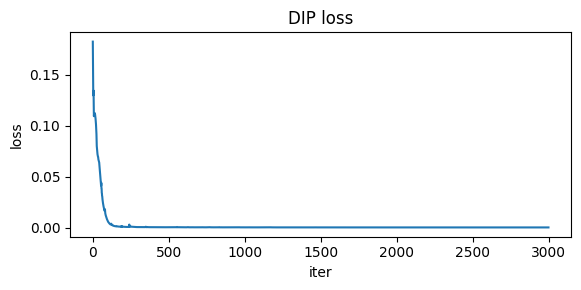

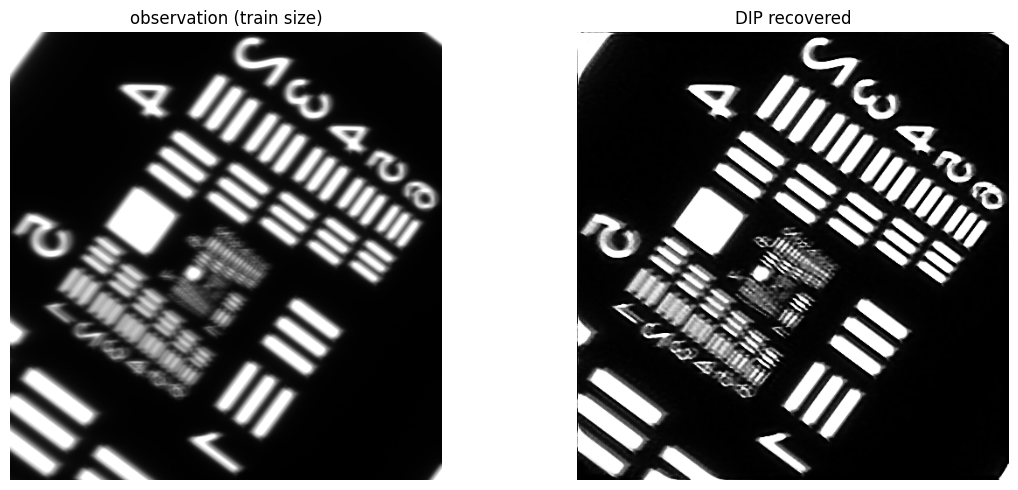

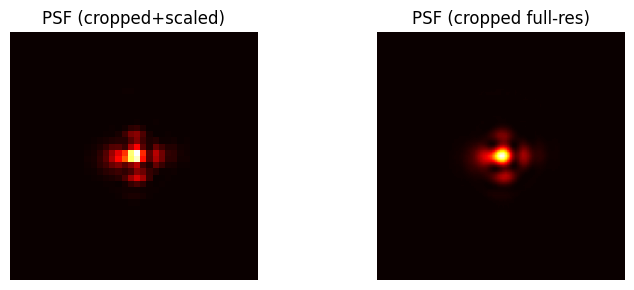

In [3]:
# ============ 路径与超参（按你的数据修改）============
IMAGE_PATH = "original_image.png"
PSF_PATH = "psf_kernel.png"
PSF_CROP_SIZE = 101  # 奇数；若点源像较大可改为 51~151
MAX_SIDE = 512       # 训练时最长边；None 表示不缩放原图（显存大）
NUM_ITER = 3000
LR = 0.01
TV_WEIGHT = 1e-6
OUT_DIR = "dip_results"

# 1) 读取观测
y = load_grayscale(IMAGE_PATH)
print("观测:", y.shape, y.min(), y.max())

# 2) PSF：从整图裁剪有效核
psf_full = load_grayscale(PSF_PATH)
psf = crop_psf_from_image(psf_full, crop_size=PSF_CROP_SIZE)
print("PSF 裁剪后:", psf.shape, "sum=", psf.sum())

# 3) 可选：同步缩小
y_train, psf_train = resize_pair_for_dip(y, psf, MAX_SIDE)
print("训练尺寸:", y_train.shape, "PSF:", psf_train.shape)

# 4) DIP
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)
recovered = dip_deconvolution(
    y_train,
    psf_train,
    num_iter=NUM_ITER,
    lr=LR,
    tv_weight=TV_WEIGHT,
    device=device,
    save_every=750,
    out_dir=OUT_DIR,
)

# 5) 保存与对比图
plt.imsave(os.path.join(OUT_DIR, "dip_final.png"), recovered, cmap="gray")
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(y_train, cmap="gray")
ax[0].set_title("observation (train size)")
ax[0].axis("off")
ax[1].imshow(recovered, cmap="gray")
ax[1].set_title("DIP recovered")
ax[1].axis("off")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "compare.png"), dpi=150)
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(8, 3))
ax[0].imshow(psf_train, cmap="hot")
ax[0].set_title("PSF (cropped+scaled)")
ax[1].imshow(psf, cmap="hot")
ax[1].set_title("PSF (cropped full-res)")
for a in ax:
    a.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "psf_check.png"), dpi=120)
plt.show()